In [5]:
# Fix version conflicts - uninstall and reinstall in correct order
%pip uninstall -y numpy scipy gensim node2vec
%pip install numpy==1.26.4
%pip install scipy==1.11.4
%pip install gensim==4.3.2
%pip install node2vec==0.4.6
print("\n✅ Installation complete! PLEASE RESTART THE RUNTIME NOW!")
print("   In Colab: Runtime → Restart Runtime")
print("   In VS Code: Click 'Restart' in kernel selector")

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: gensim 4.4.0
Uninstalling gensim-4.4.0:
  Successfully uninstalled gensim-4.4.0
Found existing installation: node2vec 0.5.0
Uninstalling node2vec-0.5.0:
  Successfully uninstalled node2vec-0.5.0
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mapclassify 2.10.0 requires scipy>=1.12, which is not installed.
osqp 1.0.5 requires scipy>=0.13.2, which is not installed.
missingno 0.5.2 requires scipy, which is not installed.
ineq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 128.1 MB/s  0:00:00m0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mapclassify 2.10.0 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
inequality 1.1.2 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
spopt 0.7.0 requires scipy>=1.12.0, but you have scipy 1.11.4 which is incompatible.
giddy 2.3.8 requires scipy>=1.12, but you have scipy 1.11.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 whi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 34.4 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gensim: filename=gensim-4.3.2-cp312-cp312-linux_x86_64.whl size=26332392 sha256=dd4edae8f16e8d09ff719bc7ad802a8bdcaca989b04488e8eaa6e2e9cae5b40a
  Stored in directory: /root/.cache/pip/wheels/50/c0/ac/7bb08954bc59d390c848b480a3fc5eec68c14bc77bf334d624
Successfully built gensim
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.8 MB/s  0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1━━━ 0/2 [networkx]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [node2vec]1/2 [node2vec]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following


✅ Installation complete! PLEASE RESTART THE RUNTIME NOW!
   In Colab: Runtime → Restart Runtime
   In VS Code: Click 'Restart' in kernel selector


In [5]:
%pip uninstall -y umap-learn
%pip install umap-learn --no-deps

Found existing installation: umap-learn 0.5.9.post2
Uninstalling umap-learn-0.5.9.post2:
  Successfully uninstalled umap-learn-0.5.9.post2


In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from node2vec import Node2Vec
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")


In [ ]:
"""this cell is for local notebooks and data"""
# email_df = pd.read_csv('../data/email-Eu-core.txt', sep=' ', skiprows=3, names=['source', 'target'])
# department_df = pd.read_csv('../data/email-Eu-core-department-labels.txt', sep=' ', skiprows=3, names=['node', 'department'])
# print(f"Email DataFrame shape: {email_df.shape}")
# print(f"Department DataFrame shape: {department_df.shape}")

In [4]:
# Download data directly from SNAP
import urllib.request
import gzip
import shutil
import os

os.makedirs('../data/raw', exist_ok=True)

print("Downloading email-Eu-core.txt...")
url_emails = 'https://snap.stanford.edu/data/email-Eu-core.txt.gz'
urllib.request.urlretrieve(url_emails, '../data/raw/email-Eu-core.txt.gz')

# Decompress
with gzip.open('../data/raw/email-Eu-core.txt.gz', 'rb') as f_in:
    with open('../data/raw/email-Eu-core.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# Download email-Eu-core-department-labels.txt
print("Downloading email-Eu-core-department-labels.txt...")
url_labels = 'https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz'
urllib.request.urlretrieve(url_labels, '../data/raw/email-Eu-core-department-labels.txt.gz')

# Decompress
with gzip.open('../data/raw/email-Eu-core-department-labels.txt.gz', 'rb') as f_in:
    with open('../data/raw/email-Eu-core-department-labels.txt', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Download complete!")

# Read the data
df_emails = pd.read_csv('../data/raw/email-Eu-core.txt', sep=' ', names=['source', 'target'], comment='#')
df_department = pd.read_csv('../data/raw/email-Eu-core-department-labels.txt', sep=' ', names=['node', 'department'])

print(f"Emails dataset: {len(df_emails)} edges")
print(f"Department labels: {len(df_department)} nodes")
print(f"Unique departments: {df_department['department'].nunique()}")

df_emails.head()

Download complete!
Emails dataset: 25571 edges
Department labels: 1005 nodes
Unique departments: 42


,source,target
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7


In [5]:
df_department.head()

,node,department
0,0,1
1,1,1
2,2,21
3,3,21
4,4,21


In [6]:
email_graph = nx.from_pandas_edgelist(df_emails, 'source', 'target')
print(f"graph has {email_graph.number_of_nodes()} nodes and {email_graph.number_of_edges()} edges.")

graph has 1005 nodes and 16706 edges.


In [10]:
clean_email_graph = email_graph.copy()
clean_email_graph.remove_edges_from(list(nx.selfloop_edges(email_graph)))
print(f"clean graph has {clean_email_graph.number_of_nodes()} nodes and {clean_email_graph.number_of_edges()} edges.")

clean graph has 1005 nodes and 16064 edges.


In [12]:
print("now removing isolated nodes that doesn't connect")
clean_email_graph.remove_nodes_from(list(nx.isolates(clean_email_graph)))
print(f"final clean graph has {clean_email_graph.number_of_nodes()} nodes and {clean_email_graph.number_of_edges()} edges.")

now removing isolated nodes that doesn't connect
final clean graph has 986 nodes and 16064 edges.


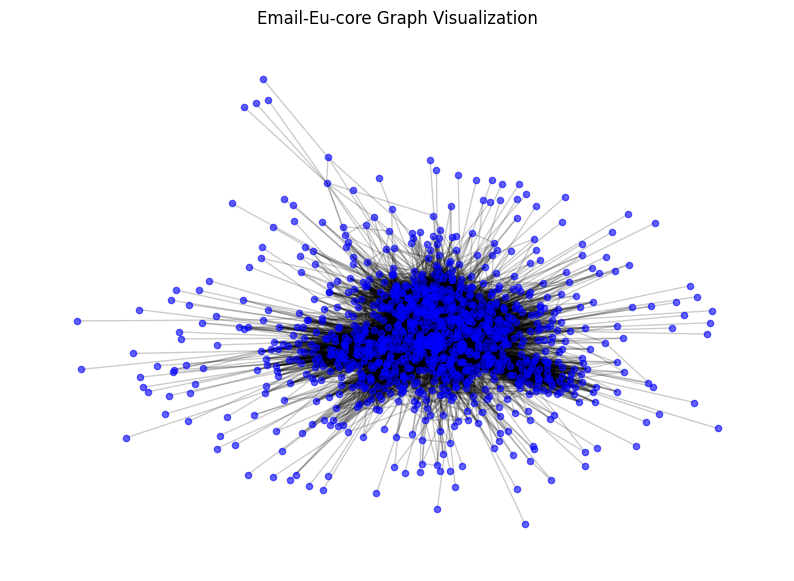

In [13]:
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(clean_email_graph, seed=42)
nx.draw_networkx_nodes(clean_email_graph, pos, node_size=20, node_color='blue', alpha=0.6)
nx.draw_networkx_edges(clean_email_graph, pos, alpha=0.2)
plt.title("Email-Eu-core Graph Visualization")
plt.axis('off')
plt.show()

In [ ]:
graph_statistics=pd.DataFrame({
    'Statistic': ['Number of Nodes', 'Number of Edges', 'Average Degree', 'Density', 'Number of Connected Components'],
    'Value': [
        clean_email_graph.number_of_nodes(),
        clean_email_graph.number_of_edges(),
        sum(dict(clean_email_graph.degree()).values()) / clean_email_graph.number_of_nodes(),
        nx.density(clean_email_graph),
        nx.number_connected_components(clean_email_graph)
    ]
    })
graph_statistics.head()

,Statistic,Value
0,Number of Nodes,986.000000
1,Number of Edges,16064.000000
2,Average Degree,32.584178
3,Density,0.033080
4,Number of Connected Components,1.000000


In [ ]:
graph_set=set(clean_email_graph.nodes())
dept_ids=set(df_department['node'].tolist())
intersection=graph_set.intersection(dept_ids)
len(intersection)
print('all nodes exists in the department df')

986

In [20]:
print('department distribution')

dept_counts = df_department['department'].value_counts().sort_values(ascending=False).reset_index()
dept_counts.columns = ['Department', 'Count']
dept_counts['percentage'] = (dept_counts['Count'] / dept_counts['Count'].sum()) * 100  
dept_counts.head()

department distribution


,Department,Count,percentage
0,4,109,10.845771
1,14,92,9.154229
2,1,65,6.467662
3,21,61,6.069652
4,15,55,5.472637


In [29]:
department_dist=pd.DataFrame({
    'Department': dept_counts['Department'],
    'Count': dept_counts['Count'],
    'Percentage': dept_counts['percentage'],
}).set_index('Department')
department_dist.head(8)

,Count,Percentage
Department,,
4,109,10.845771
14,92,9.154229
1,65,6.467662
21,61,6.069652
15,55,5.472637
7,51,5.074627
0,49,4.875622
10,39,3.880597


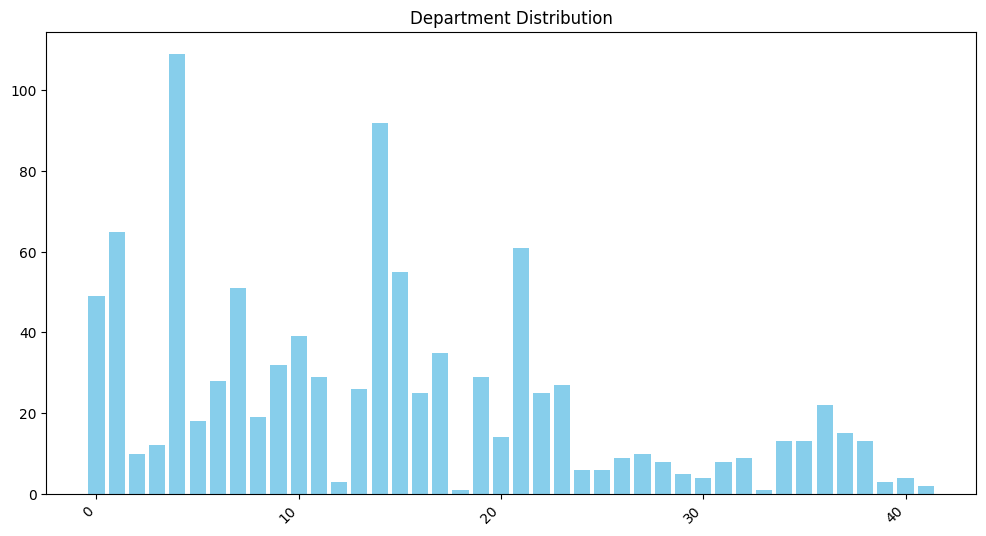

In [30]:
plt.figure(figsize=(12, 6))
plt.bar(dept_counts['Department'], dept_counts['Count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Department Distribution')
plt.show()


In [36]:
dept_stats = pd.DataFrame({
    'Metric': [
        'Most Common Department',
        'Least Common Department', 
        'Max Count',
        'Min Count',
        'Imbalance Ratio',
        'Departments < 2 samples',
        'Departments ≤ 10 samples'
    ],
    'Value': [
        dept_counts['Department'].iloc[0],  # Most common
        dept_counts['Department'].iloc[-1],  # Least common
        dept_counts['Count'].iloc[0],  # Highest count
        dept_counts['Count'].iloc[-1],  # Lowest count
        dept_counts['Count'].iloc[0] / dept_counts['Count'].iloc[-1],  # Ratio
        sum(dept_counts['Count'] < 2),  # Count < 2
        sum(dept_counts['Count'] <= 10)  # Count <= 10
    ]
})

dept_stats

,Metric,Value
0,Most Common Department,4.0
1,Least Common Department,33.0
2,Max Count,109.0
3,Min Count,1.0
4,Imbalance Ratio,109.0
5,Departments < 2 samples,2.0
6,Departments ≤ 10 samples,16.0


In [ ]:
print('Filtering departments with insufficient samples for stratified splitting')
print('For 70/15/15 split with stratification, need at least 7 samples per department')

# Require at least 7 samples per department to ensure stratified splits work
df_dept_filtered = df_department.groupby('department').filter(lambda x: len(x) >= 7)
filtered_email_graph = clean_email_graph.copy()
filtered_email_graph.remove_nodes_from([node for node in filtered_email_graph.nodes() if node not in df_dept_filtered['node'].values])
print(f"filtered graph has {filtered_email_graph.number_of_nodes()} nodes and {filtered_email_graph.number_of_edges()} edges.")

dept with less than 2 samples causes stratifying problems we consider them as outlier and removing them 
filtered graph has 984 nodes and 16055 edges.


In [43]:
print('final data distibution')
df_dept_filtered_count=df_dept_filtered['department'].value_counts().sort_values(ascending=False).reset_index()
df_dept_filtered_count.columns = ['department', 'count']
df_dept_filtered_count['percentage'] = (df_dept_filtered_count['count'] / df_dept_filtered_count['count'].sum()) * 100
df_dept_filtered_count.head()




final data distibution


,department,count,percentage
0,4,109,10.867398
1,14,92,9.172483
2,1,65,6.480558
3,21,61,6.081755
4,15,55,5.483549


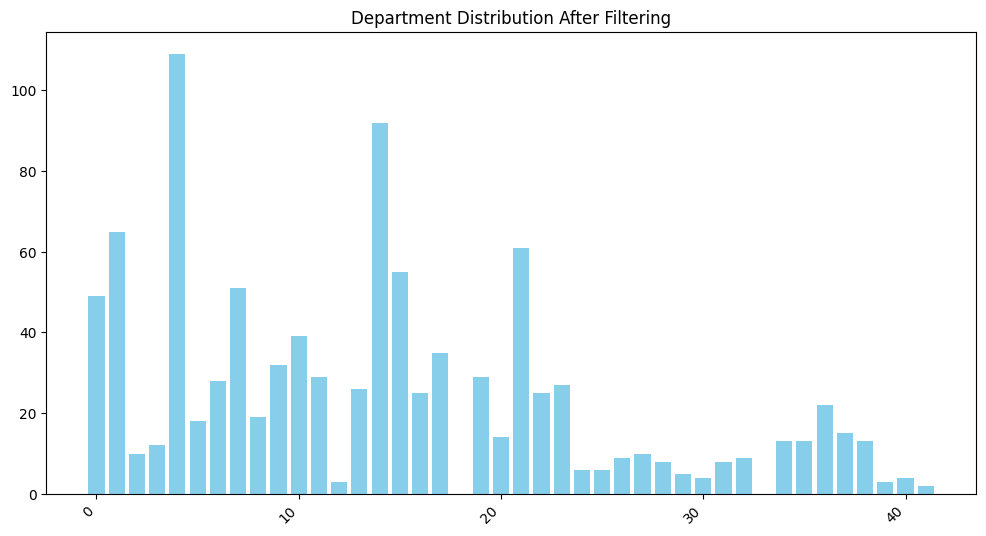

In [44]:
plt.figure(figsize=(12, 6))
plt.bar(df_dept_filtered_count['department'], df_dept_filtered_count['count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Department Distribution After Filtering')
plt.show()

adding embeddings using node2vec

In [ ]:

model = Node2Vec(
    filtered_email_graph,
    dimensions=128,
    walk_length=80,
    num_walks=10,
    workers=4,
    p=1,
    q=1,
    seed=42,
    quiet=False
)

embeddings= model.fit(
    window=10,
    min_count=1,
    epochs=20,
    sg=1,
    )

Computing transition probabilities:   0%|          | 0/984 [00:00<?, ?it/s]

In [56]:
print('total graph nodes',len(filtered_email_graph.nodes()))
print('total embeddings nodes',len(
embeddings.wv.index_to_key))

total graph nodes 984
total embeddings nodes 984


In [62]:
print('nodes of graph and vocab size is equal')
embeddings.vector_size


nodes of graph and vocab size is equal


128

In [72]:
print('sample of embedings vectors')
embeddings.wv[800]

sample of embedings vectors


array([ 3.0001512e-01, -6.7921005e-02, -1.4036208e-01, -9.3854822e-02,
       -1.9748690e-02,  4.2778971e-03,  3.0344236e-01,  9.5749839e-04,
       -4.9215278e-01, -9.3235999e-02, -5.0262835e-02, -5.5378586e-01,
        8.5395038e-02, -4.6609378e-01, -2.7441779e-01, -4.0973046e-01,
       -1.6426560e-01,  4.9931172e-01, -4.3136549e-01,  1.1811310e-02,
        4.2085171e-01, -1.9477567e-01, -5.3708196e-01, -1.4336547e-01,
        3.9172366e-01,  1.6888484e-01,  2.3721505e-02,  9.5010504e-02,
       -2.7873123e-01, -6.1086094e-01, -3.9281937e-01, -1.3824056e-01,
        5.8172818e-04, -1.7701429e-01, -3.7052700e-01,  1.9941585e-02,
       -6.9373173e-01,  3.8972190e-01, -2.0762633e-01, -3.1052160e-01,
       -1.9633903e-03, -1.1479456e-01,  8.0899082e-02,  6.0298782e-02,
        2.4253140e-01, -5.3527121e-02, -4.0670419e-01,  3.6988050e-02,
        3.8442427e-01,  9.1629958e-04, -2.7297791e-03, -1.4153995e-01,
       -1.9197656e-01,  9.9054255e-02,  1.8283673e-01,  2.4943607e-01,
      

In [73]:
df_dept_filtered.head()

,node,department
0,0,1
1,1,1
2,2,21
3,3,21
4,4,21


In [74]:
embeddings_list=[] #x list
labels_list=[] #y list
nodes_list=[] #traking list
for row in df_dept_filtered.itertuples():
    node_id=str(row.node)
    if node_id in embeddings.wv:
        emb_vector=embeddings.wv[node_id]
        embeddings_list.append(emb_vector)
        labels_list.append(row.department)
        nodes_list.append(node_id)
    else:
        print(f'node id {node_id} not found in embeddings')

node id 580 not found in embeddings
node id 633 not found in embeddings
node id 648 not found in embeddings
node id 653 not found in embeddings
node id 658 not found in embeddings
node id 660 not found in embeddings
node id 670 not found in embeddings
node id 675 not found in embeddings
node id 684 not found in embeddings
node id 691 not found in embeddings
node id 703 not found in embeddings
node id 711 not found in embeddings
node id 731 not found in embeddings
node id 732 not found in embeddings
node id 744 not found in embeddings
node id 746 not found in embeddings
node id 772 not found in embeddings
node id 798 not found in embeddings
node id 808 not found in embeddings


In [78]:
X=np.array(embeddings_list)
y=np.array(labels_list)
X.shape, y.shape

((984, 128), (984,))

In [79]:
coverage=len(embeddings_list)/len(filtered_email_graph.nodes())*100
print(f'Embeddings coverage of nodes in the graph: {coverage:.2f}%')

Embeddings coverage of nodes in the graph: 100.00%


In [80]:
print('all the nodes are explained by the embeddings')

all the nodes are explained by the embeddings


In [82]:
print('null values count',np.isnan(X).sum())
print('y type',type(y), y.shape)

null values count 0
y type <class 'numpy.ndarray'> (984,)


In [83]:
print('unique departments in y',np.unique(y))

unique departments in y [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 34 35 36 37 38 39 40 41]


Downlaod intermediate model localy (just run it when working on colab cloud with vs code )

In [84]:
# ============================================================================
# SAVE AND DOWNLOAD NODE2VEC MODELS DIRECTLY
# ============================================================================

print("\n" + "=" * 80)
print("💾 SAVING AND DOWNLOADING NODE2VEC MODELS")
print("=" * 80)

import numpy as np
import json
import os
import zipfile
import base64
from IPython.display import HTML, display
from datetime import datetime

# Step 1: Save models locally in Colab
print("\n📦 Step 1: Saving models in Colab storage...")
colab_models_dir = '/tmp/node2vec_models'
os.makedirs(colab_models_dir, exist_ok=True)

# Save Node2Vec word vectors
print("   Saving Node2Vec model...")
embeddings.wv.save(os.path.join(colab_models_dir, 'node2vec_model.wv'))
print("   ✅ Saved: node2vec_model.wv")

# Save embedding arrays
print("   Saving embedding arrays...")
np.save(os.path.join(colab_models_dir, 'X_embeddings.npy'), X)
np.save(os.path.join(colab_models_dir, 'y_labels.npy'), y)
np.save(os.path.join(colab_models_dir, 'node_ids.npy'), np.array(nodes_list))
print("   ✅ Saved: X_embeddings.npy")
print("   ✅ Saved: y_labels.npy")
print("   ✅ Saved: node_ids.npy")

# Save metadata
print("   Saving metadata...")
metadata = {
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'hyperparameters': {
        'dimensions': 128,
        'walk_length': 80,
        'num_walks': 10,
        'window': 10,
        'epochs': 20,
        'p': 1,
        'q': 1,
        'workers': 4,
        'sg': 1
    },
    'data_info': {
        'total_graph_nodes': len(filtered_email_graph.nodes()),
        'total_samples': len(X),
        'embedding_dimension': int(X.shape[1]),
        'num_departments': int(len(np.unique(y))),
        'coverage_percentage': float(coverage),
        'unique_departments': [int(d) for d in np.unique(y)]
    },
    'class_distribution': {
        int(dept): int(count) 
        for dept, count in zip(*np.unique(y, return_counts=True))
    },
    'data_quality': {
        'nan_values': int(np.isnan(X).sum()),
        'inf_values': int(np.isinf(X).sum()),
        'X_min': float(X.min()),
        'X_max': float(X.max()),
        'X_mean': float(X.mean()),
        'X_std': float(X.std())
    }
}

with open(os.path.join(colab_models_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)
print("   ✅ Saved: metadata.json")

# Save department distribution
dept_distribution = pd.DataFrame({
    'department': [int(d) for d in df_dept_filtered_count['department']],
    'count': [int(c) for c in df_dept_filtered_count['count']],
    'percentage': [float(p) for p in df_dept_filtered_count['percentage']]
})
dept_distribution.to_csv(os.path.join(colab_models_dir, 'department_distribution.csv'), index=False)
print("   ✅ Saved: department_distribution.csv")

# Save README
readme_content = f"""
# Node2Vec Email-EU-Core Models

**Training Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Files Included

1. **node2vec_model.wv** - Trained Word2Vec model (embeddings)
2. **X_embeddings.npy** - Feature matrix (shape: {X.shape})
3. **y_labels.npy** - Department labels (shape: {y.shape})
4. **node_ids.npy** - Node IDs for tracking
5. **metadata.json** - Training configuration and statistics
6. **department_distribution.csv** - Class distribution
7. **README.txt** - This file

## Model Performance

- **Total Nodes:** {len(filtered_email_graph.nodes())}
- **Embedding Coverage:** {coverage:.2f}%
- **Embedding Dimension:** {X.shape[1]}
- **Departments:** {len(np.unique(y))}
- **Samples:** {len(X)}

## Hyperparameters

- Dimensions: 128
- Walk Length: 80
- Num Walks: 10
- Window: 10
- Epochs: 20
- p: 1
- q: 1

## How to Load

```python
import numpy as np
from gensim.models import KeyedVectors
import json

# Load embeddings
X = np.load('X_embeddings.npy')
y = np.load('y_labels.npy')
node_ids = np.load('node_ids.npy')

# Load Node2Vec model
embeddings = KeyedVectors.load('node2vec_model.wv')

# Load metadata
with open('metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"X shape: {{X.shape}}")
print(f"y shape: {{y.shape}}")
print(f"Coverage: {{metadata['data_info']['coverage_percentage']:.2f}}%")
```

## Next Steps

Use these embeddings for:
1. Department classification (supervised learning)
2. Visualization (PCA/t-SNE/UMAP)
3. Clustering analysis
4. Node similarity search

## Directory Structure

Place files in:
```
email-eu-graph-platform/
├── models/
│   ├── node2vec_model.wv
│   ├── X_embeddings.npy
│   ├── y_labels.npy
│   ├── node_ids.npy
│   ├── metadata.json
│   ├── department_distribution.csv
│   └── README.txt
```

Generated by: Node2Vec Training Pipeline
"""

with open(os.path.join(colab_models_dir, 'README.txt'), 'w') as f:
    f.write(readme_content)
print("   ✅ Saved: README.txt")

# Step 2: Create zip file
print("\n📦 Step 2: Creating zip archive...")
zip_path = '/tmp/node2vec_trained_models.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(colab_models_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, colab_models_dir)
            zipf.write(file_path, arcname)
            file_size_kb = os.path.getsize(file_path) / 1024
            print(f"   Added: {arcname} ({file_size_kb:.1f} KB)")

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\n✅ Zip created: {zip_path} ({zip_size_mb:.2f} MB)")

# Step 3: Create download link
print("\n📥 Step 3: Creating download link...")

with open(zip_path, 'rb') as f:
    b64_data = base64.b64encode(f.read()).decode()

download_link = f'''
<div style="padding: 20px; background-color: #e3f2fd; border-radius: 10px; margin: 20px 0; border-left: 5px solid #2196F3;">
    <h2 style="color: #1976D2; margin-top: 0;">📥 Download Node2Vec Models</h2>
    
    <div style="background: white; padding: 15px; border-radius: 5px; margin: 15px 0;">
        <h3 style="color: #333; margin-top: 0;">📊 Model Summary</h3>
        <ul style="color: #666; line-height: 1.8;">
            <li><strong>File Size:</strong> {zip_size_mb:.2f} MB</li>
            <li><strong>Samples:</strong> {len(X):,}</li>
            <li><strong>Embedding Dimension:</strong> {X.shape[1]}</li>
            <li><strong>Departments:</strong> {len(np.unique(y))}</li>
            <li><strong>Coverage:</strong> {coverage:.2f}%</li>
            <li><strong>Training Date:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M')}</li>
        </ul>
    </div>
    
    <a download="node2vec_trained_models.zip" 
       href="data:application/zip;base64,{b64_data}"
       style="display: inline-block; padding: 15px 30px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
              color: white; text-decoration: none; border-radius: 8px; font-weight: bold; font-size: 16px;
              box-shadow: 0 4px 6px rgba(0,0,0,0.1); transition: transform 0.2s;">
        ⬇️ Download node2vec_trained_models.zip
    </a>
    
    <div style="margin-top: 20px; padding: 15px; background: #fff3cd; border-radius: 5px; border-left: 4px solid #ffc107;">
        <strong>📁 Extract to:</strong><br>
        <code style="background: #fff; padding: 8px; border-radius: 3px; display: inline-block; margin-top: 5px; color: #d32f2f;">
            c:\\Users\\Dell\\Desktop\\Dev\\AI-projects\\email-eu-graph-platform\\models\\
        </code>
    </div>
    
    <div style="margin-top: 15px; padding: 10px; background: #e8f5e9; border-radius: 5px; font-size: 13px;">
        <strong>✅ Files Included:</strong>
        <ul style="margin: 5px 0; padding-left: 20px;">
            <li>node2vec_model.wv (Word2Vec model)</li>
            <li>X_embeddings.npy (Features)</li>
            <li>y_labels.npy (Labels)</li>
            <li>node_ids.npy (Node tracking)</li>
            <li>metadata.json (Training info)</li>
            <li>department_distribution.csv</li>
            <li>README.txt</li>
        </ul>
    </div>
</div>
'''

display(HTML(download_link))

print("\n" + "=" * 80)
print("✅ DOWNLOAD LINK CREATED!")
print("=" * 80)
print(f"""
📋 SUMMARY:
-----------
✅ Models saved and compressed successfully!
✅ Zip file size: {zip_size_mb:.2f} MB
✅ Total samples: {len(X):,}
✅ Embedding dimension: {X.shape[1]}
✅ Departments: {len(np.unique(y))}
✅ Coverage: {coverage:.2f}%

📥 DOWNLOAD INSTRUCTIONS:
-------------------------
1. Click the purple download button above ⬆️
2. Save to your Downloads folder
3. Extract the zip file to:
   c:\\Users\\Dell\\Desktop\\Dev\\AI-projects\\email-eu-graph-platform\\models\\

⚠️  If button doesn't work in VS Code:
   → Open notebook in browser (https://colab.research.google.com)
   → Run this cell
   → Click download button

📄 FILES INCLUDED:
------------------
""")

for filename in sorted(os.listdir(colab_models_dir)):
    file_path = os.path.join(colab_models_dir, filename)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"   • {filename:<35} ({size_kb:>8.1f} KB)")

print("\n" + "=" * 80)


💾 SAVING AND DOWNLOADING NODE2VEC MODELS

📦 Step 1: Saving models in Colab storage...
   Saving Node2Vec model...
   ✅ Saved: node2vec_model.wv
   Saving embedding arrays...
   ✅ Saved: X_embeddings.npy
   ✅ Saved: y_labels.npy
   ✅ Saved: node_ids.npy
   Saving metadata...
   ✅ Saved: metadata.json
   ✅ Saved: department_distribution.csv
   ✅ Saved: README.txt

📦 Step 2: Creating zip archive...
   Added: node_ids.npy (15.5 KB)
   Added: X_embeddings.npy (492.1 KB)
   Added: department_distribution.csv (1.0 KB)
   Added: y_labels.npy (7.8 KB)
   Added: README.txt (1.7 KB)
   Added: metadata.json (2.0 KB)
   Added: node2vec_model.wv (516.9 KB)

✅ Zip created: /tmp/node2vec_trained_models.zip (0.91 MB)

📥 Step 3: Creating download link...



✅ DOWNLOAD LINK CREATED!

📋 SUMMARY:
-----------
✅ Models saved and compressed successfully!
✅ Zip file size: 0.91 MB
✅ Total samples: 984
✅ Embedding dimension: 128
✅ Departments: 40
✅ Coverage: 100.00%

📥 DOWNLOAD INSTRUCTIONS:
-------------------------
1. Click the purple download button above ⬆️
2. Save to your Downloads folder
3. Extract the zip file to:
   c:\Users\Dell\Desktop\Dev\AI-projects\email-eu-graph-platform\models\

⚠️  If button doesn't work in VS Code:
   → Open notebook in browser (https://colab.research.google.com)
   → Run this cell
   → Click download button

📄 FILES INCLUDED:
------------------

   • README.txt                          (     1.7 KB)
   • X_embeddings.npy                    (   492.1 KB)
   • department_distribution.csv         (     1.0 KB)
   • metadata.json                       (     2.0 KB)
   • node2vec_model.wv                   (   516.9 KB)
   • node_ids.npy                        (    15.5 KB)
   • y_labels.npy                        ( 

In [86]:
print('samples per department in y labels')
unique, counts = np.unique(y, return_counts=True)
dept_sample_counts = dict(zip(unique, counts))
dept_sample_counts

samples per department in y labels


{0: 49,
 1: 62,
 2: 10,
 3: 12,
 4: 107,
 5: 18,
 6: 28,
 7: 49,
 8: 19,
 9: 31,
 10: 39,
 11: 29,
 12: 3,
 13: 26,
 14: 91,
 15: 54,
 16: 24,
 17: 34,
 19: 29,
 20: 13,
 21: 56,
 22: 25,
 23: 27,
 24: 6,
 25: 6,
 26: 9,
 27: 10,
 28: 8,
 29: 5,
 30: 4,
 31: 8,
 32: 9,
 34: 12,
 35: 13,
 36: 22,
 37: 15,
 38: 13,
 39: 3,
 40: 4,
 41: 2}

In [93]:
print('deps with under 2 samples are', [dept for dept, count in dept_sample_counts.items() if count <= 2])
print('number of samples by department sorted')
sorted(dept_sample_counts.items(), key=lambda x: x[1])

deps with under 2 samples are [41]
number of samples by department sorted


[(41, 2),
 (12, 3),
 (39, 3),
 (30, 4),
 (40, 4),
 (29, 5),
 (24, 6),
 (25, 6),
 (28, 8),
 (31, 8),
 (26, 9),
 (32, 9),
 (2, 10),
 (27, 10),
 (3, 12),
 (34, 12),
 (20, 13),
 (35, 13),
 (38, 13),
 (37, 15),
 (5, 18),
 (8, 19),
 (36, 22),
 (16, 24),
 (22, 25),
 (13, 26),
 (23, 27),
 (6, 28),
 (11, 29),
 (19, 29),
 (9, 31),
 (17, 34),
 (10, 39),
 (0, 49),
 (7, 49),
 (15, 54),
 (21, 56),
 (1, 62),
 (14, 91),
 (4, 107)]

In [96]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: Try stratified, fallback to random if needed
try:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    print('✅ Validation/Test split: Stratified')
except ValueError as e:
    print(f'⚠️  Stratification failed: {e}')
    print('   Using random split for val/test (this is fine for evaluation sets)')
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    print('✅ Validation/Test split: Random')

print('\n📊 Final Split:')
print(f'Train set:      {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation set: {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test set:       {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)')
print('✅ Split completed successfully')

⚠️  Stratification failed: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
   Using random split for val/test (this is fine for evaluation sets)
✅ Validation/Test split: Random

📊 Final Split:
Train set:      (688, 128) (69.9%)
Validation set: (148, 128) (15.0%)
Test set:       (148, 128) (15.0%)
✅ Split completed successfully


In [ ]:
from turtle import mode
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('classifier', LogisticRegression(max_iter=200, random_state=42,class_weight='balanced'))
])

models={
    'Logistic Regression':LogisticRegression(max_iter=200, random_state=42,class_weight='balanced'),
    'Random Forest':RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced'),
    'SVM':SVC(random_state=42,class_weight='balanced'),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=100, random_state=42),
}

model_performance={}
for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    pipeline.set_params(classifier=model)
    pipeline.fit(X_train, y_train)
    
    train_accuracy=pipeline.score(X_train, y_train)
    val_accuracy=pipeline.score(X_val, y_val)
    test_accuracy=pipeline.score(X_test, y_test)
    
    model_performance[model_name]={
        'Train Accuracy':train_accuracy,
        'Validation Accuracy':val_accuracy,
        'Test Accuracy':test_accuracy,
    }
    
    print(f'{model_name} - Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')


Training Logistic Regression...
Logistic Regression - Train Accuracy: 1.0000, Validation Accuracy: 0.7432, Test Accuracy: 0.7703

Training Random Forest...
Random Forest - Train Accuracy: 1.0000, Validation Accuracy: 0.6351, Test Accuracy: 0.7095

Training SVM...
SVM - Train Accuracy: 0.9724, Validation Accuracy: 0.7230, Test Accuracy: 0.7500

Training Gradient Boosting...
Gradient Boosting - Train Accuracy: 1.0000, Validation Accuracy: 0.4932, Test Accuracy: 0.6014


📊 DETAILED MODEL EVALUATION ON TEST SET

🔍 EVALUATING: Logistic Regression

📈 Overall Performance Metrics:
Metric          Train        Validation   Test        
-------------------------------------------------------
Accuracy             1.0000      0.7432      0.7703
Precision            1.0000      0.7547      0.7624
Recall               1.0000      0.7432      0.7703
F1-Score             1.0000      0.7273      0.7556

📊 Confusion Matrix (Test Set):
[[7 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 1 0]
 [0 1 0 ... 0 0 0]]


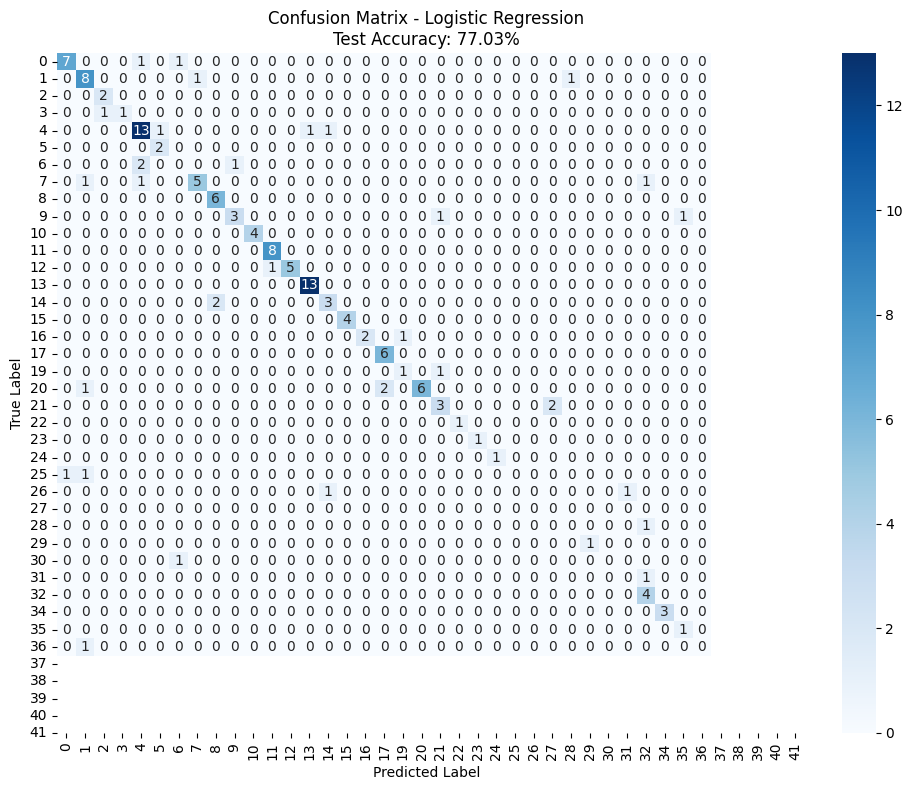


--------------------------------------------------------------------------------

🔍 EVALUATING: Random Forest

📈 Overall Performance Metrics:
Metric          Train        Validation   Test        
-------------------------------------------------------
Accuracy             1.0000      0.6351      0.7095
Precision            1.0000      0.6185      0.6656
Recall               1.0000      0.6351      0.7095
F1-Score             1.0000      0.5778      0.6643

📊 Confusion Matrix (Test Set):
[[5 0 0 ... 0 0 0]
 [0 9 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


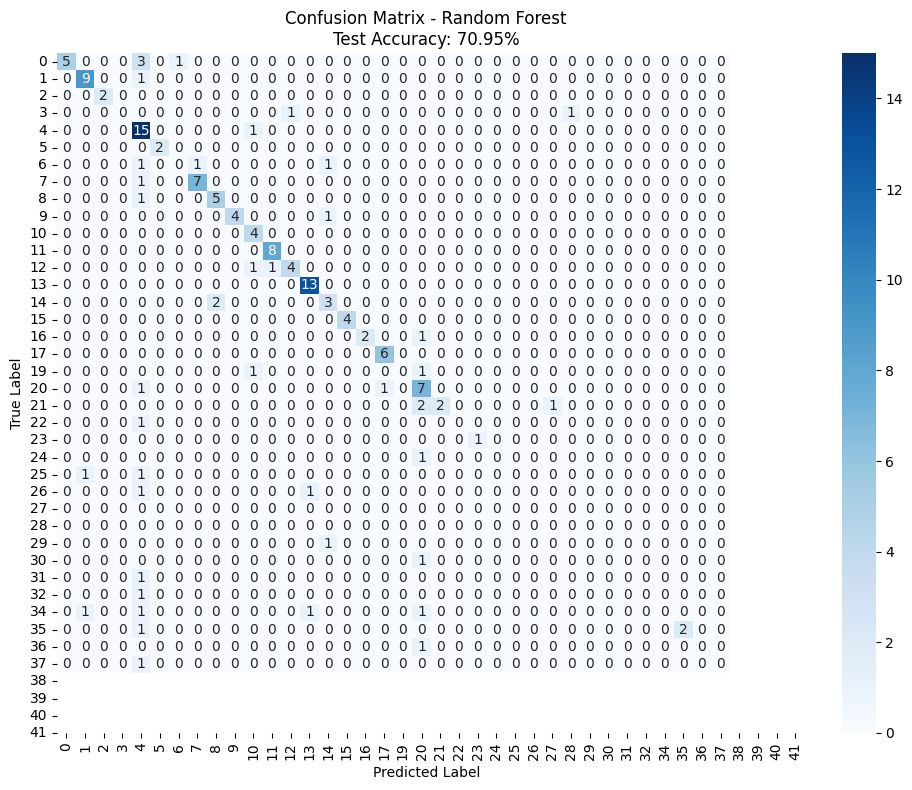


--------------------------------------------------------------------------------

🔍 EVALUATING: SVM

📈 Overall Performance Metrics:
Metric          Train        Validation   Test        
-------------------------------------------------------
Accuracy             0.9724      0.7230      0.7500
Precision            0.9758      0.7412      0.7854
Recall               0.9724      0.7230      0.7500
F1-Score             0.9727      0.7130      0.7462

📊 Confusion Matrix (Test Set):
[[ 6  0  0 ...  0  0  0]
 [ 0 10  0 ...  0  0  0]
 [ 0  0  1 ...  0  0  0]
 ...
 [ 0  0  0 ...  2  0  0]
 [ 0  0  0 ...  0  1  0]
 [ 0  0  0 ...  0  0  0]]


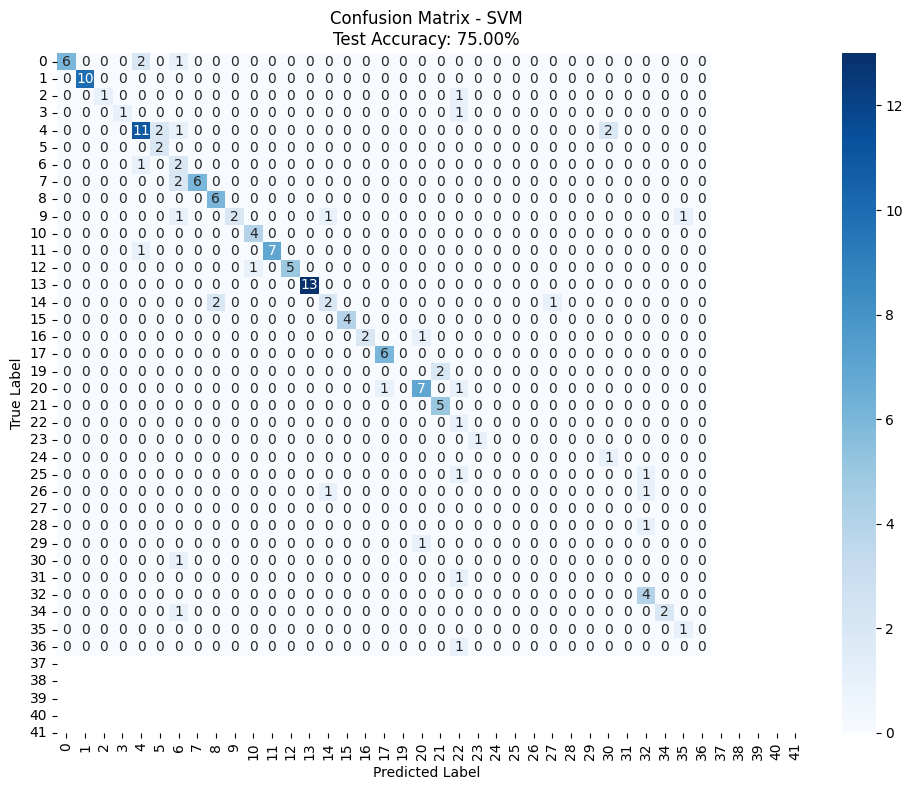


--------------------------------------------------------------------------------

🔍 EVALUATING: Gradient Boosting

📈 Overall Performance Metrics:
Metric          Train        Validation   Test        
-------------------------------------------------------
Accuracy             1.0000      0.4932      0.6014
Precision            1.0000      0.4618      0.6427
Recall               1.0000      0.4932      0.6014
F1-Score             1.0000      0.4555      0.6004

📊 Confusion Matrix (Test Set):
[[6 0 0 ... 0 0 0]
 [0 8 0 ... 0 0 0]
 [0 0 1 ... 1 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


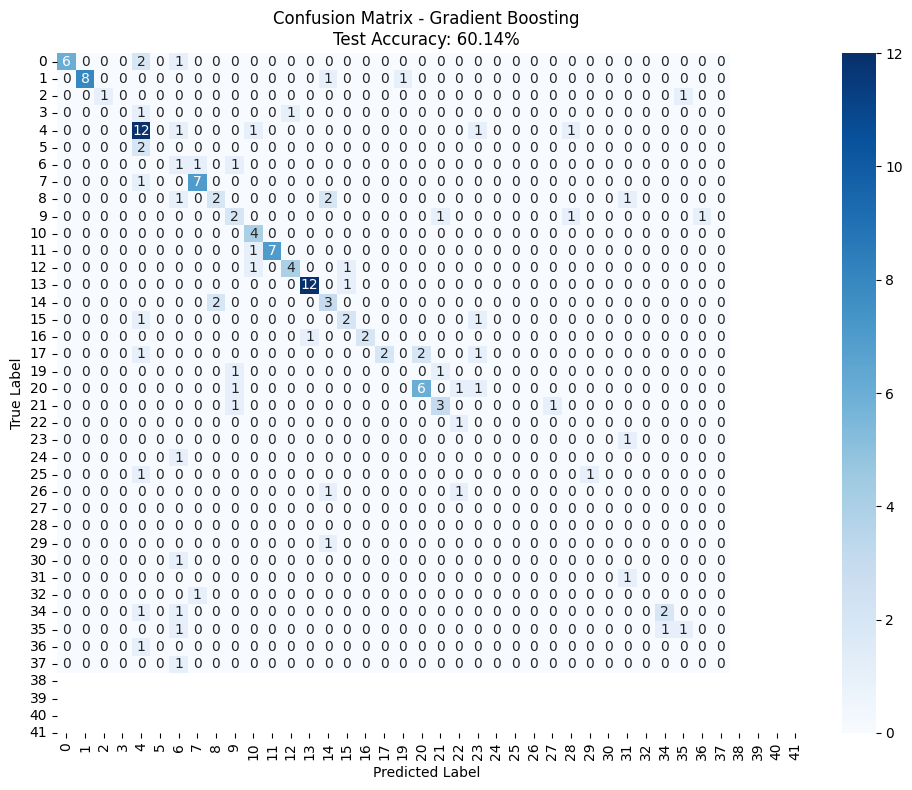


--------------------------------------------------------------------------------

📋 FINAL MODEL COMPARISON
              Model  Train Acc  Val Acc  Test Acc  Test Precision  Test Recall  Test F1
Logistic Regression     1.0000   0.7432    0.7703          0.7624       0.7703   0.7556
      Random Forest     1.0000   0.6351    0.7095          0.6656       0.7095   0.6643
                SVM     0.9724   0.7230    0.7500          0.7854       0.7500   0.7462
  Gradient Boosting     1.0000   0.4932    0.6014          0.6427       0.6014   0.6004

🏆 BEST MODEL: Logistic Regression
   Test F1-Score: 0.7556
   Test Accuracy: 0.7703

✅ EVALUATION COMPLETE FOR ALL MODELS


In [104]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 80)
print("📊 DETAILED MODEL EVALUATION ON TEST SET")
print("=" * 80)

# Store overall results for comparison
overall_results = []

for model_name, model in models.items():
    print("\n" + "=" * 80)
    print(f"🔍 EVALUATING: {model_name}")
    print("=" * 80)
    
    # Fit the pipeline with this specific model
    pipeline.set_params(classifier=model)
    pipeline.fit(X_train, y_train)
    
    # Make predictions on all sets
    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)
    y_test_pred = pipeline.predict(X_test)
    
    # Get accuracy scores
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Get overall precision, recall, f1 (weighted average)
    train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
        y_train, y_train_pred, average='weighted', zero_division=0
    )
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
        y_val, y_val_pred, average='weighted', zero_division=0
    )
    test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
        y_test, y_test_pred, average='weighted', zero_division=0
    )
    
    # Store results
    overall_results.append({
        'Model': model_name,
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'Test Acc': test_acc,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1': test_f1
    })
    
    # Print overall metrics
    print(f"\n📈 Overall Performance Metrics:")
    print(f"{'Metric':<15} {'Train':<12} {'Validation':<12} {'Test':<12}")
    print("-" * 55)
    print(f"{'Accuracy':<15} {train_acc:>11.4f} {val_acc:>11.4f} {test_acc:>11.4f}")
    print(f"{'Precision':<15} {train_precision:>11.4f} {val_precision:>11.4f} {test_precision:>11.4f}")
    print(f"{'Recall':<15} {train_recall:>11.4f} {val_recall:>11.4f} {test_recall:>11.4f}")
    print(f"{'F1-Score':<15} {train_f1:>11.4f} {val_f1:>11.4f} {test_f1:>11.4f}")
    
    # Confusion Matrix
    print(f"\n📊 Confusion Matrix (Test Set):")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y), 
                yticklabels=np.unique(y))
    plt.title(f'Confusion Matrix - {model_name}\nTest Accuracy: {test_acc:.2%}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "-" * 80)

# Final comparison table
print("\n" + "=" * 80)
print("📋 FINAL MODEL COMPARISON")
print("=" * 80)

comparison_df = pd.DataFrame(overall_results)
comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))

# Find best model
best_model_idx = comparison_df['Test F1'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_f1 = comparison_df.loc[best_model_idx, 'Test F1']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test F1-Score: {best_f1:.4f}")
print(f"   Test Accuracy: {comparison_df.loc[best_model_idx, 'Test Acc']:.4f}")

print("\n" + "=" * 80)
print("✅ EVALUATION COMPLETE FOR ALL MODELS")
print("=" * 80)

visualizing embeddings with PCA, t-SNE and UMAP


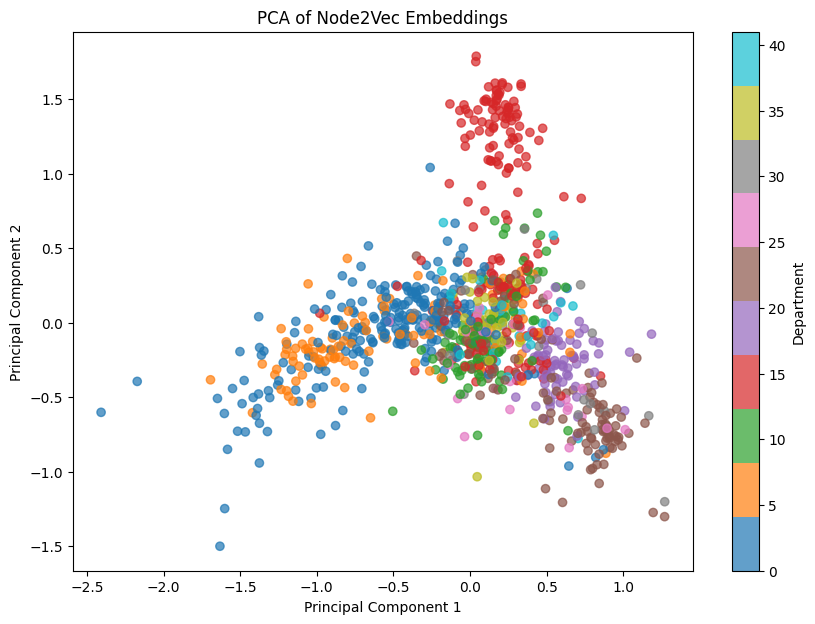

In [111]:
print('visualizing embeddings with PCA, t-SNE and UMAP')

# PCA Visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('PCA of Node2Vec Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Department')
plt.show()


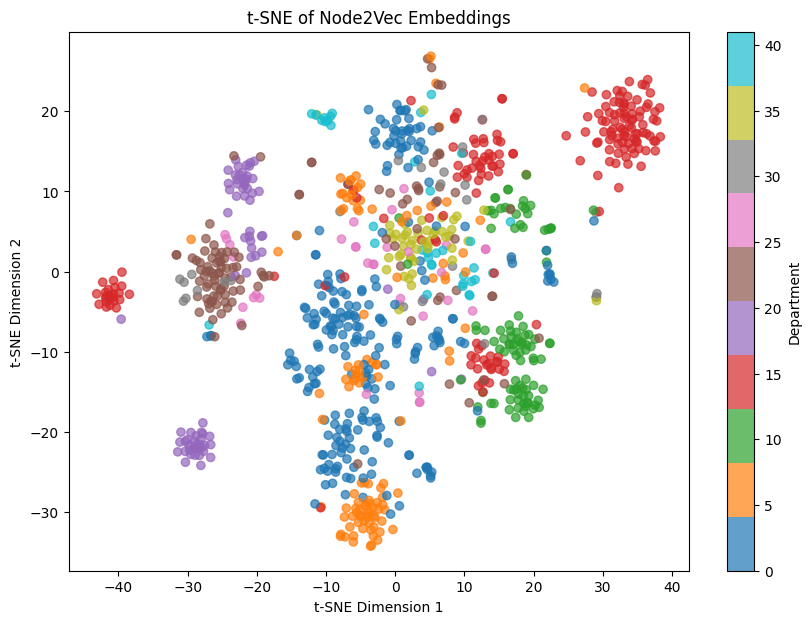

In [106]:
# t-SNE Visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30
)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('t-SNE of Node2Vec Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Department')
plt.show()


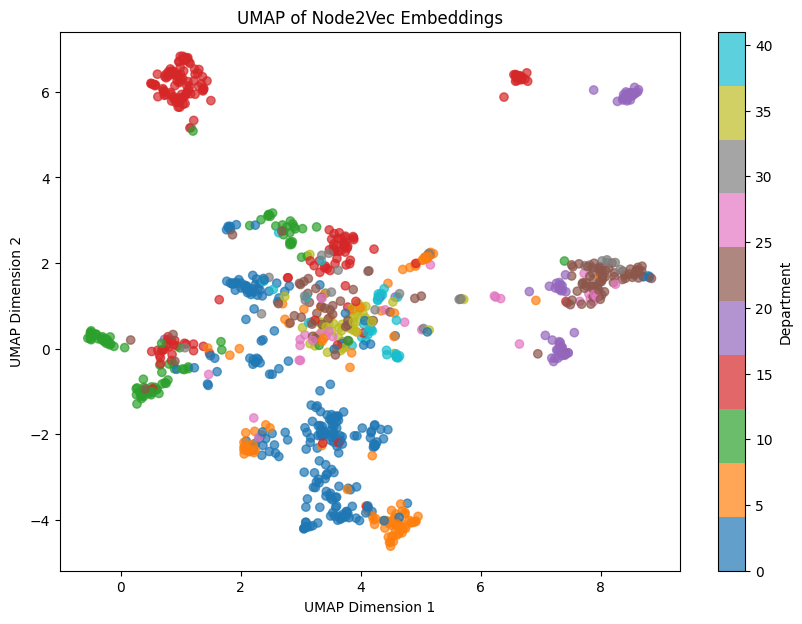

In [107]:
#umap Visualization
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('UMAP of Node2Vec Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.colorbar(scatter, label='Department')
plt.show()


comaparaison between visualizations


saving model using download link(only for vscode colab environment
) 

In [112]:
# ============================================================================
# PHASE 7: SAVE EVERYTHING - TRAINED MODELS & RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("💾 PHASE 7: SAVING TRAINED MODELS & RESULTS")
print("=" * 80)

import numpy as np
import json
import os
import zipfile
import base64
import pickle
from IPython.display import HTML, display
from datetime import datetime

# Step 1: Create save directory
print("\n📦 Step 1: Creating save directory...")
save_dir = '/tmp/trained_models'
os.makedirs(save_dir, exist_ok=True)
print(f"   ✅ Directory created: {save_dir}")

# Step 2: Save Node2Vec Model
print("\n🔷 Step 2: Saving Node2Vec model...")
embeddings.wv.save(os.path.join(save_dir, 'node2vec_model.wv'))
print("   ✅ Saved: node2vec_model.wv (for generating new embeddings)")

# Step 3: Save Best Classifier
print("\n🏆 Step 3: Saving best classifier...")
# Get the best model from comparison
best_model_name = comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Model']
best_model = models[best_model_name]

# Retrain pipeline with best model on full training data
pipeline.set_params(classifier=best_model)
pipeline.fit(X_train, y_train)

# Save the trained pipeline (includes scaler + classifier)
with open(os.path.join(save_dir, 'best_classifier.pkl'), 'wb') as f:
    pickle.dump(pipeline, f)
print(f"   ✅ Saved: best_classifier.pkl ({best_model_name})")

# Step 4: Save Embeddings
print("\n📊 Step 4: Saving embeddings and labels...")
np.save(os.path.join(save_dir, 'X_embeddings.npy'), X)
np.save(os.path.join(save_dir, 'y_labels.npy'), y)
np.save(os.path.join(save_dir, 'node_ids.npy'), np.array(nodes_list))
print("   ✅ Saved: X_embeddings.npy")
print("   ✅ Saved: y_labels.npy")
print("   ✅ Saved: node_ids.npy")

# Step 5: Save Train/Val/Test Splits
print("\n🔀 Step 5: Saving train/val/test splits...")
np.save(os.path.join(save_dir, 'X_train.npy'), X_train)
np.save(os.path.join(save_dir, 'X_val.npy'), X_val)
np.save(os.path.join(save_dir, 'X_test.npy'), X_test)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'y_val.npy'), y_val)
np.save(os.path.join(save_dir, 'y_test.npy'), y_test)
print("   ✅ Saved: Train/Val/Test splits (6 files)")

# Step 6: Save Model Comparison Results
print("\n📈 Step 6: Saving model comparison results...")
comparison_df.to_csv(os.path.join(save_dir, 'model_comparison.csv'), index=False)
print("   ✅ Saved: model_comparison.csv")

# Step 7: Save Metadata
print("\n📄 Step 7: Creating metadata file...")
metadata = {
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    
    'best_model': {
        'name': best_model_name,
        'test_accuracy': float(comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Acc']),
        'test_f1_score': float(comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test F1']),
        'test_precision': float(comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Precision']),
        'test_recall': float(comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Recall']),
        'validation_accuracy': float(comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Val Acc']),
        'train_accuracy': float(comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Train Acc'])
    },
    
    'node2vec_parameters': {
        'dimensions': 128,
        'walk_length': 80,
        'num_walks': 10,
        'window': 10,
        'epochs': 20,
        'p': 1,
        'q': 1,
        'workers': 4,
        'sg': 1
    },
    
    'data_info': {
        'total_samples': int(len(X)),
        'train_samples': int(len(X_train)),
        'validation_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'embedding_dimension': int(X.shape[1]),
        'num_departments': int(len(np.unique(y))),
        'unique_departments': [int(d) for d in sorted(np.unique(y))],
        'total_graph_nodes': len(filtered_email_graph.nodes()),
        'embedding_coverage': float(coverage)
    },
    
    'class_distribution': {
        int(dept): int(count) 
        for dept, count in zip(*np.unique(y, return_counts=True))
    },
    
    'train_val_test_split': {
        'train_ratio': 0.70,
        'validation_ratio': 0.15,
        'test_ratio': 0.15,
        'stratified_train': True,
        'stratified_val_test': 'attempted'
    },
    
    'all_models_tested': {
        row['Model']: {
            'test_accuracy': float(row['Test Acc']),
            'test_f1': float(row['Test F1']),
            'test_precision': float(row['Test Precision']),
            'test_recall': float(row['Test Recall'])
        }
        for _, row in comparison_df.iterrows()
    },
    
    'data_quality': {
        'nan_values': int(np.isnan(X).sum()),
        'inf_values': int(np.isinf(X).sum()),
        'X_min': float(X.min()),
        'X_max': float(X.max()),
        'X_mean': float(X.mean()),
        'X_std': float(X.std())
    }
}

with open(os.path.join(save_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)
print("   ✅ Saved: metadata.json")

# Step 8: Create README
print("\n📝 Step 8: Creating README file...")
readme_content = f"""
# Email-EU-Core: Trained Models & Results
**Training Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 🎯 Model Performance Summary

### Best Model: {best_model_name}
- **Test Accuracy:** {comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Acc']:.4f}
- **Test F1-Score:** {comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test F1']:.4f}
- **Test Precision:** {comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Precision']:.4f}
- **Test Recall:** {comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Recall']:.4f}

### All Models Tested
{comparison_df.to_string(index=False)}

## 📦 Files Included

### 1. Models
- **node2vec_model.wv** - Trained Node2Vec embeddings (for generating new node embeddings)
- **best_classifier.pkl** - Best performing classifier ({best_model_name} + StandardScaler)

### 2. Data
- **X_embeddings.npy** - Full embedding matrix (shape: {X.shape})
- **y_labels.npy** - Department labels (shape: {y.shape})
- **node_ids.npy** - Node IDs for tracking

### 3. Train/Val/Test Splits
- **X_train.npy, y_train.npy** - Training set ({len(X_train)} samples)
- **X_val.npy, y_val.npy** - Validation set ({len(X_val)} samples)
- **X_test.npy, y_test.npy** - Test set ({len(X_test)} samples)

### 4. Results & Metadata
- **model_comparison.csv** - Performance of all tested models
- **metadata.json** - Complete training configuration and statistics
- **README.txt** - This file

## 🔧 Data Statistics
- **Total Samples:** {len(X):,}
- **Embedding Dimension:** {X.shape[1]}
- **Number of Departments:** {len(np.unique(y))}
- **Graph Nodes:** {len(filtered_email_graph.nodes())}
- **Embedding Coverage:** {coverage:.2f}%

## 🚀 How to Use

### Load Node2Vec Model (for new embeddings)
```python
from gensim.models import KeyedVectors

# Load Node2Vec model
embeddings = KeyedVectors.load('node2vec_model.wv')

# Get embedding for a specific node
node_embedding = embeddings.wv['node_id']

# Find similar nodes
similar_nodes = embeddings.wv.most_similar('node_id', topn=10)
```

### Load Best Classifier (for predictions)
```python
import pickle
import numpy as np

# Load the trained classifier
with open('best_classifier.pkl', 'rb') as f:
    classifier = pickle.load(f)

# Load test data
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

# Make predictions
predictions = classifier.predict(X_test)

# Get prediction probabilities (if supported)
if hasattr(classifier, 'predict_proba'):
    probabilities = classifier.predict_proba(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuracy: {{accuracy_score(y_test, predictions):.4f}}")
print(classification_report(y_test, predictions))
```

### Load Full Dataset
```python
import numpy as np
import json

# Load embeddings
X = np.load('X_embeddings.npy')
y = np.load('y_labels.npy')
node_ids = np.load('node_ids.npy')

# Load metadata
with open('metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"X shape: {{X.shape}}")
print(f"Best model: {{metadata['best_model']['name']}}")
print(f"Test accuracy: {{metadata['best_model']['test_accuracy']:.4f}}")
```

### Load Specific Split
```python
import numpy as np

# Load training data
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')

# Load validation data
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')

# Load test data
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')
```

## 📊 Node2Vec Hyperparameters
- **Dimensions:** 128
- **Walk Length:** 80
- **Number of Walks:** 10
- **Window Size:** 10
- **Epochs:** 20
- **p (Return parameter):** 1
- **q (In-out parameter):** 1

## 📁 Recommended Directory Structure
```
email-eu-graph-platform/
├── models/
│   ├── node2vec_model.wv           # Node2Vec embeddings
│   ├── best_classifier.pkl         # Best trained classifier
│   ├── X_embeddings.npy            # Full embeddings
│   ├── y_labels.npy                # Labels
│   ├── node_ids.npy                # Node tracking
│   ├── X_train.npy, y_train.npy   # Training split
│   ├── X_val.npy, y_val.npy       # Validation split
│   ├── X_test.npy, y_test.npy     # Test split
│   ├── model_comparison.csv        # All models performance
│   ├── metadata.json               # Training metadata
│   └── README.txt                  # This file
```

## 🎓 Next Steps

1. **Production Deployment**
   - Use `best_classifier.pkl` for real-time predictions
   - Load Node2Vec model to generate embeddings for new nodes

2. **Model Improvement**
   - Try different Node2Vec parameters (p, q values)
   - Experiment with ensemble methods
   - Feature engineering on embeddings

3. **Analysis**
   - Visualize embeddings (PCA, t-SNE, UMAP)
   - Analyze misclassifications
   - Study department relationships

4. **Monitoring**
   - Track prediction accuracy over time
   - Update model periodically with new data

## ⚠️ Important Notes
- The classifier expects **scaled** input (StandardScaler is included in pipeline)
- Node IDs are stored as strings in the Node2Vec model
- All departments have at least 7 samples (filtered during preprocessing)

---
Generated by: Email-EU-Core Classification Pipeline
Training completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

with open(os.path.join(save_dir, 'README.txt'), 'w') as f:
    f.write(readme_content)
print("   ✅ Saved: README.txt")

# Step 9: Create ZIP file
print("\n📦 Step 9: Creating ZIP archive...")
zip_path = '/tmp/trained_models_complete.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(save_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, save_dir)
            zipf.write(file_path, arcname)
            file_size_kb = os.path.getsize(file_path) / 1024
            print(f"   Added: {arcname:<30} ({file_size_kb:>8.1f} KB)")

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\n✅ ZIP created: {zip_path} ({zip_size_mb:.2f} MB)")

# Step 10: Create Download Link
print("\n📥 Step 10: Creating download link...")

with open(zip_path, 'rb') as f:
    b64_data = base64.b64encode(f.read()).decode()

download_link = f'''
<div style="padding: 25px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); border-radius: 15px; margin: 25px 0; box-shadow: 0 10px 40px rgba(0,0,0,0.2);">
    <h1 style="color: white; margin-top: 0; font-size: 28px;">🎉 PHASE 7 COMPLETE: TRAINED MODELS READY!</h1>
    
    <div style="background: white; padding: 20px; border-radius: 10px; margin: 20px 0;">
        <h2 style="color: #333; margin-top: 0; border-bottom: 3px solid #667eea; padding-bottom: 10px;">📊 Training Summary</h2>
        
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 15px; margin: 15px 0;">
            <div style="background: #e3f2fd; padding: 15px; border-radius: 8px; border-left: 4px solid #2196F3;">
                <strong style="color: #1976D2; font-size: 18px;">🏆 Best Model</strong><br>
                <span style="font-size: 24px; color: #333; font-weight: bold;">{best_model_name}</span>
            </div>
            <div style="background: #e8f5e9; padding: 15px; border-radius: 8px; border-left: 4px solid #4CAF50;">
                <strong style="color: #388E3C; font-size: 18px;">🎯 Test Accuracy</strong><br>
                <span style="font-size: 24px; color: #333; font-weight: bold;">{comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Acc']:.2%}</span>
            </div>
            <div style="background: #fff3e0; padding: 15px; border-radius: 8px; border-left: 4px solid #FF9800;">
                <strong style="color: #F57C00; font-size: 18px;">📈 Test F1-Score</strong><br>
                <span style="font-size: 24px; color: #333; font-weight: bold;">{comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test F1']:.4f}</span>
            </div>
            <div style="background: #fce4ec; padding: 15px; border-radius: 8px; border-left: 4px solid #E91E63;">
                <strong style="color: #C2185B; font-size: 18px;">💾 File Size</strong><br>
                <span style="font-size: 24px; color: #333; font-weight: bold;">{zip_size_mb:.2f} MB</span>
            </div>
        </div>
        
        <h3 style="color: #333; margin-top: 25px; border-bottom: 2px solid #eee; padding-bottom: 8px;">📦 Package Contents</h3>
        <ul style="color: #666; line-height: 2.0; font-size: 14px;">
            <li><strong>node2vec_model.wv</strong> - Trained embeddings (generate new node vectors)</li>
            <li><strong>best_classifier.pkl</strong> - {best_model_name} + StandardScaler (ready for predictions)</li>
            <li><strong>X/y embeddings & labels</strong> - Full dataset ({len(X):,} samples)</li>
            <li><strong>Train/Val/Test splits</strong> - Preprocessed data splits</li>
            <li><strong>model_comparison.csv</strong> - Performance of all {len(comparison_df)} models</li>
            <li><strong>metadata.json</strong> - Complete training configuration & statistics</li>
            <li><strong>README.txt</strong> - Usage instructions & examples</li>
        </ul>
        
        <h3 style="color: #333; margin-top: 25px; border-bottom: 2px solid #eee; padding-bottom: 8px;">📊 Data Overview</h3>
        <div style="background: #f5f5f5; padding: 15px; border-radius: 8px; font-family: monospace; font-size: 13px;">
            <strong>Total Samples:</strong> {len(X):,}<br>
            <strong>Embedding Dimension:</strong> {X.shape[1]}<br>
            <strong>Departments:</strong> {len(np.unique(y))}<br>
            <strong>Train/Val/Test:</strong> {len(X_train)}/{len(X_val)}/{len(X_test)} ({len(X_train)/len(X)*100:.0f}%/{len(X_val)/len(X)*100:.0f}%/{len(X_test)/len(X)*100:.0f}%)<br>
            <strong>Graph Nodes:</strong> {len(filtered_email_graph.nodes()):,}<br>
            <strong>Coverage:</strong> {coverage:.2f}%
        </div>
    </div>
    
    <a download="trained_models_complete.zip" 
       href="data:application/zip;base64,{b64_data}"
       style="display: inline-block; padding: 20px 40px; background: white; color: #667eea;
              text-decoration: none; border-radius: 10px; font-weight: bold; font-size: 20px;
              box-shadow: 0 5px 15px rgba(0,0,0,0.2); transition: all 0.3s;
              border: 3px solid white;">
        ⬇️ DOWNLOAD TRAINED MODELS ({zip_size_mb:.2f} MB)
    </a>
    
    <div style="margin-top: 25px; padding: 20px; background: rgba(255,255,255,0.2); border-radius: 10px; color: white;">
        <strong style="font-size: 18px;">📁 Extract to:</strong><br>
        <code style="background: rgba(0,0,0,0.3); padding: 10px 15px; border-radius: 5px; display: inline-block; margin-top: 10px; font-size: 14px;">
            c:\\Users\\Dell\\Desktop\\Dev\\AI-projects\\email-eu-graph-platform\\models\\
        </code>
    </div>
</div>

<div style="background: #f5f5f5; padding: 20px; border-radius: 10px; margin-top: 20px; border-left: 5px solid #4CAF50;">
    <h3 style="color: #2E7D32; margin-top: 0;">✅ Quick Start Guide</h3>
    <pre style="background: #263238; color: #aed581; padding: 15px; border-radius: 5px; overflow-x: auto; font-size: 13px;">
<span style="color: #ffab40;">import</span> pickle
<span style="color: #ffab40;">import</span> numpy <span style="color: #ffab40;">as</span> np

<span style="color: #78909c;"># Load best classifier</span>
<span style="color: #ffab40;">with</span> <span style="color: #81c784;">open</span>(<span style="color: #80cbc4;">'best_classifier.pkl'</span>, <span style="color: #80cbc4;">'rb'</span>) <span style="color: #ffab40;">as</span> f:
    classifier = pickle.<span style="color: #81c784;">load</span>(f)

<span style="color: #78909c;"># Load test data</span>
X_test = np.<span style="color: #81c784;">load</span>(<span style="color: #80cbc4;">'X_test.npy'</span>)
y_test = np.<span style="color: #81c784;">load</span>(<span style="color: #80cbc4;">'y_test.npy'</span>)

<span style="color: #78909c;"># Make predictions</span>
predictions = classifier.<span style="color: #81c784;">predict</span>(X_test)

<span style="color: #81c784;">print</span>(<span style="color: #80cbc4;">f"Predictions: {{predictions[:5]}}"</span>)
    </pre>
</div>
'''

display(HTML(download_link))

# Step 11: Print Summary
print("\n" + "=" * 80)
print("🎉 PHASE 7 COMPLETE!")
print("=" * 80)
print(f"""
✅ ALL MODELS AND RESULTS SAVED SUCCESSFULLY!

📦 PACKAGE SUMMARY:
-------------------
Best Model:        {best_model_name}
Test Accuracy:     {comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test Acc']:.4f}
Test F1-Score:     {comparison_df.loc[comparison_df['Test F1'].idxmax(), 'Test F1']:.4f}
Package Size:      {zip_size_mb:.2f} MB

📄 FILES INCLUDED ({len(os.listdir(save_dir))} files):
--------------------------------------------------
""")

for filename in sorted(os.listdir(save_dir)):
    file_path = os.path.join(save_dir, filename)
    size_kb = os.path.getsize(file_path) / 1024
    if size_kb > 1024:
        size_str = f"{size_kb/1024:>6.2f} MB"
    else:
        size_str = f"{size_kb:>6.1f} KB"
    print(f"   • {filename:<30} {size_str:>10}")

print(f"""
📥 DOWNLOAD INSTRUCTIONS:
-------------------------
1. Click the download button above ⬆️
2. Save to your Downloads folder
3. Extract to: c:\\Users\\Dell\\Desktop\\Dev\\AI-projects\\email-eu-graph-platform\\models\\

🚀 READY FOR PRODUCTION:
------------------------
✅ Node2Vec model ready to generate embeddings for new nodes
✅ Best classifier ready for department predictions
✅ All data splits preserved for reproducibility
✅ Complete metadata for tracking

""")
print("=" * 80)
print("✅ PROJECT COMPLETE - ALL PHASES FINISHED!")
print("=" * 80)


💾 PHASE 7: SAVING TRAINED MODELS & RESULTS

📦 Step 1: Creating save directory...
   ✅ Directory created: /tmp/trained_models

🔷 Step 2: Saving Node2Vec model...
   ✅ Saved: node2vec_model.wv (for generating new embeddings)

🏆 Step 3: Saving best classifier...
   ✅ Saved: best_classifier.pkl (Logistic Regression)

📊 Step 4: Saving embeddings and labels...
   ✅ Saved: X_embeddings.npy
   ✅ Saved: y_labels.npy
   ✅ Saved: node_ids.npy

🔀 Step 5: Saving train/val/test splits...
   ✅ Saved: Train/Val/Test splits (6 files)

📈 Step 6: Saving model comparison results...
   ✅ Saved: model_comparison.csv

📄 Step 7: Creating metadata file...
   ✅ Saved: metadata.json

📝 Step 8: Creating README file...
   ✅ Saved: README.txt

📦 Step 9: Creating ZIP archive...
   Added: node_ids.npy                   (    15.5 KB)
   Added: model_comparison.csv           (     0.3 KB)
   Added: y_test.npy                     (     1.3 KB)
   Added: y_val.npy                      (     1.3 KB)
   Added: X_embedding


🎉 PHASE 7 COMPLETE!

✅ ALL MODELS AND RESULTS SAVED SUCCESSFULLY!

📦 PACKAGE SUMMARY:
-------------------
Best Model:        Logistic Regression
Test Accuracy:     0.7703
Test F1-Score:     0.7556
Package Size:      1.40 MB

📄 FILES INCLUDED (14 files):
--------------------------------------------------

   • README.txt                         5.2 KB
   • X_embeddings.npy                 492.1 KB
   • X_test.npy                        74.1 KB
   • X_train.npy                      344.1 KB
   • X_val.npy                         74.1 KB
   • best_classifier.pkl               44.7 KB
   • metadata.json                      3.3 KB
   • model_comparison.csv               0.3 KB
   • node2vec_model.wv                517.0 KB
   • node_ids.npy                      15.5 KB
   • y_labels.npy                       7.8 KB
   • y_test.npy                         1.3 KB
   • y_train.npy                        5.5 KB
   • y_val.npy                          1.3 KB

📥 DOWNLOAD INSTRUCTIONS:
---------